In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import networkx as nx
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from scipy.cluster.hierarchy import dendrogram
print("Imported all libraries!")

Imported all libraries!


## Loading the data

In [2]:
df = None

if os.path.exists("./data/df.parquet"): # checks if parquet file exists
    print("./data/df.parquet exists")
    df = pd.read_parquet("./data/df.parquet")
else: # create the parquet file bc man ts takes too long
    print("./data/df.parquet doesn't exist")
    dataframes = []

    for i in range(4): #loading data
        dataframes.append(pd.read_json(f"./data/dblp-ref-{i}.json", lines=True))
        print(f"dblp-ref-{i}.json loaded successfully!")

    df = pd.concat(dataframes, ignore_index=True)
    df.to_parquet("./data/df.parquet")

print("dataframe loaded successfully")
df.head()

./data/df.parquet exists
dataframe loaded successfully


,abstract,authors,n_citation,references,title,venue,year,id
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",0,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,00127ee2-cb05-48ce-bc49-9de556b93346
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",50,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,2011,001c58d3-26ad-46b3-ab3a-c1e557d16821
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",50,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,001c8744-73c4-4b04-9364-22d31a10dbf1
3,NaN,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",0,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,2011,00338203-9eb3-40c5-9f31-cbac73a519ec
4,NaN,"[Giovanna Guerrini, Isabella Merlo]",2,None,Reasonig about Set-Oriented Methods in Object ...,,1998,0040b022-1472-4f70-a753-74832df65266


## A1: Preprocessing

In [3]:
# normalize venue/title strings
df['venue'] = df['venue'].str.strip().str.lower()
df['title'] = df['title'].str.strip().str.lower()

# diagnostic: check ACL candidates BEFORE dropping rows with no abstract
# (ACL papers may exist in the data but lack abstracts)
acl_candidates = df[df['venue'].str.contains(
    'computational linguistics|association for computational|natural language proc', na=False, regex=True
)]['venue'].value_counts()
print("ACL-like venues (before abstract filter):\n", acl_candidates.head(10), "\n")

# drop nulls & empty strings
df = df.dropna(subset=['venue', 'title', 'abstract'])
df = df[(df['venue'] != "") & (df['title'] != "")]
print(f"After null/empty drop: {len(df)} rows")

# parquet round-trips list columns as numpy arrays â€” accept any sequence
df = df[df['authors'].apply(lambda x: x is not None and hasattr(x, '__len__') and len(x) > 0)]
df = df[df['venue'] != 'arxiv']
df = df.drop_duplicates(subset=['id'])
print(f"After authors/arXiv/dedup: {len(df)} rows")

# confirmed venue strings from DBLP V10 (full English names, lowercase)
# if ACL-like venues printed 0 above, we swap in EMNLP or drop it
acl_venue = acl_candidates.index[0] if len(acl_candidates) > 0 else None

target_venues = [
    'international conference on machine learning',   # ICML
    'knowledge discovery and data mining',            # KDD
    'international conference on management of data', # SIGMOD
    'computer vision and pattern recognition',        # CVPR (confirmed)
    'very large data bases',                          # VLDB
]
if acl_venue:
    target_venues.append(acl_venue)
    print(f"Using ACL venue: '{acl_venue}'")
else:
    # ACL has no abstracts in this dataset â€” substitute EMNLP
    nlp_alt = df[df['venue'].str.contains('empirical methods|emnlp', na=False, regex=True)]['venue'].value_counts()
    print("No ACL found. NLP alternatives:\n", nlp_alt.head(5))
    if len(nlp_alt) > 0:
        target_venues.append(nlp_alt.index[0])
        print(f"Using NLP substitute: '{nlp_alt.index[0]}'")

print(f"\nTarget venues: {target_venues}\n")

df_filtered = df[df['venue'].isin(target_venues)]
print(f"Papers found per venue:\n{df_filtered['venue'].value_counts()}\n")

if len(df_filtered) == 0:
    print("STILL EMPTY â€” top 30 actual venue strings:\n", df['venue'].value_counts().head(30))
    raise RuntimeError("No papers matched â€” update target_venues using the list above.")

df = df_filtered

# sample up to 3000 papers per venue (~18k total)
sampled = []
for venue in target_venues:
    subset = df[df['venue'] == venue]
    if len(subset) > 0:
        sampled.append(subset.sample(n=min(len(subset), 3000), random_state=42))
df = pd.concat(sampled, ignore_index=True)
print(f"After sampling â€” papers per venue:\n{df['venue'].value_counts()}")
print(f"Total: {len(df)}\n")

# apply TF-IDF
df['text'] = df['title'] + ' ' + df['abstract']
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', min_df=5)
tfidf_matrix = vectorizer.fit_transform(df['text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

sp.save_npz('./data/tfidf_matrix.npz', tfidf_matrix)
import pickle
with open('./data/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# paper level
df = df.reset_index(drop=True)
df.to_parquet('./data/df_clean.parquet')

# author-level
author_df = df.explode('authors').rename(columns={'authors': 'author'})
author_df = author_df.groupby('author').agg(
    paper_count   = ('id', 'count'),
    avg_citations = ('n_citation', 'mean'),
    venues        = ('venue', lambda x: list(x.unique())),
    year_min      = ('year', 'min'),
    year_max      = ('year', 'max')
).reset_index()
author_df['venue_count'] = author_df['venues'].apply(len)
print(f"Author-level shape: {author_df.shape}")

# venue-level
venue_df = df.groupby('venue').agg(
    paper_count   = ('id', 'count'),
    avg_citations = ('n_citation', 'mean'),
    year_min      = ('year', 'min'),
    year_max      = ('year', 'max'),
    top_authors   = ('authors', lambda x: pd.Series([a for sublist in x for a in sublist]).value_counts().index[:5].tolist())
).reset_index()
print(f"Venue-level shape: {venue_df.shape}")

venues = venue_df['venue'].tolist()

# average TF-IDF vectors per venue
# .to_numpy() converts pandas boolean Series to numpy array for scipy sparse indexing
venue_tfidf = np.zeros((len(venues), tfidf_matrix.shape[1]))
for i, venue in enumerate(venues):
    mask = (df['venue'] == venue).to_numpy()
    venue_tfidf[i] = np.asarray(tfidf_matrix[mask].mean(axis=0)).flatten()
print(f"Venue TF-IDF matrix shape: {venue_tfidf.shape}")

scaler_z = StandardScaler()
venue_tfidf_zscore = scaler_z.fit_transform(venue_tfidf)
scaler_mm = MinMaxScaler()
venue_tfidf_minmax = scaler_mm.fit_transform(venue_tfidf)

pca = PCA(n_components=2, random_state=42)
venue_pca = pca.fit_transform(venue_tfidf_zscore)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

venue_df['pca_x'] = venue_pca[:, 0]
venue_df['pca_y'] = venue_pca[:, 1]

np.save('./data/venue_tfidf.npy', venue_tfidf)
np.save('./data/venue_tfidf_zscore.npy', venue_tfidf_zscore)
np.save('./data/venue_tfidf_minmax.npy', venue_tfidf_minmax)
venue_df.to_parquet('./data/venue_df.parquet')
author_df.to_parquet('./data/author_df.parquet')

print("All outputs saved!")
venue_df.head()

ACL-like venues (before abstract filter):
 venue
meeting of the association for computational linguistics                               4740
international conference on computational linguistics                                  4351
north american chapter of the association for computational linguistics                2679
empirical methods in natural language processing                                       2020
conference of the european chapter of the association for computational linguistics     783
international joint conference on natural language processing                           730
computational linguistics                                                               720
recent advances in natural language processing                                          389
conference on intelligent text processing and computational linguistics                 190
logical aspects of computational linguistics                                            148
Name: count, dtype: int64 

Aft

,venue,paper_count,avg_citations,year_min,year_max,top_authors,pca_x,pca_y
0,computer vision and pattern recognition,3000,101.991333,1988,2017,"[Thomas S. Huang, Takeo Kanade, Xiaoou Tang, T...",-21.055018,-11.803739
1,international conference on machine learning,3000,88.349333,1987,2017,"[Michael I. Jordan, Zoubin Ghahramani, Shie Ma...",-19.994248,-13.060607
2,international conference on management of data,3000,111.758333,1970,2017,"[Michael Stonebraker, Hector Garcia-Molina, Je...",26.327045,0.492855
3,knowledge discovery and data mining,3000,84.565667,1994,2017,"[Jiawei Han, Christos Faloutsos, Philip S. Yu,...",0.785415,-5.049509
4,meeting of the association for computational l...,3000,74.624333,1979,2016,"[Christopher D. Manning, Ido Dagan, Daniel N. ...",-12.625423,33.177842


## A2: EDA

In [4]:
# ── A2: EDA — load outputs from A1 ──────────────────────────────────────────
df          = pd.read_parquet('./data/df_clean.parquet')
venue_df    = pd.read_parquet('./data/venue_df.parquet')
tfidf_matrix = sp.load_npz('./data/tfidf_matrix.npz')
author_df   = pd.read_parquet('./data/author_df.parquet')
with open('./data/vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
feature_names = vectorizer.get_feature_names_out()

venue_abbr = {
    'computer vision and pattern recognition':                 'CVPR',
    'international conference on machine learning':            'ICML',
    'international conference on management of data':          'SIGMOD',
    'knowledge discovery and data mining':                     'KDD',
    'meeting of the association for computational linguistics': 'ACL',
    'very large data bases':                                   'VLDB',
}
venues    = venue_df['venue'].tolist()
abbr_list = [venue_abbr[v] for v in venues]
palette   = dict(zip(abbr_list, sns.color_palette('tab10', len(abbr_list))))
df['abbr'] = df['venue'].map(venue_abbr)

print(f"df: {df.shape}  |  venue_df: {venue_df.shape}  |  TF-IDF: {tfidf_matrix.shape}")
df.head(3)


df: (18000, 10)  |  venue_df: (6, 8)  |  TF-IDF: (18000, 1000)


,abstract,authors,n_citation,references,title,venue,year,id,text,abbr
0,This paper presents a Support Vector Method fo...,[Thorsten Joachims],724,"[09f87c01-bc0e-4668-b464-63d60fa7a7d5, 27389e3...",a support vector method for multivariate perfo...,international conference on machine learning,2005,cfea40f7-7c61-497c-8be7-284aa479552d,a support vector method for multivariate perfo...,ICML
1,Semi-Supervised Support Vector Machines (S 3 V...,"[Olivier Chapelle, Mingmin Chi, Alexander Zien]",152,"[261aefde-fbe5-494f-afd7-c771aff03127, 2700228...",a continuation method for semi-supervised svms,international conference on machine learning,2006,2cad1b12-4733-413d-b158-d1298e6a5633,a continuation method for semi-supervised svms...,ICML
2,Motivated by applications in domains such as s...,"[Yuxin Chen, Govinda M. Kamath, Changho Suh, D...",7,"[10d125fa-b98d-4942-8270-6c63ce1c5890, 182520e...",community recovery in graphs with locality,international conference on machine learning,2016,c2f6af0e-8d94-4b4f-a3d8-5b051630c54c,community recovery in graphs with locality Mot...,ICML


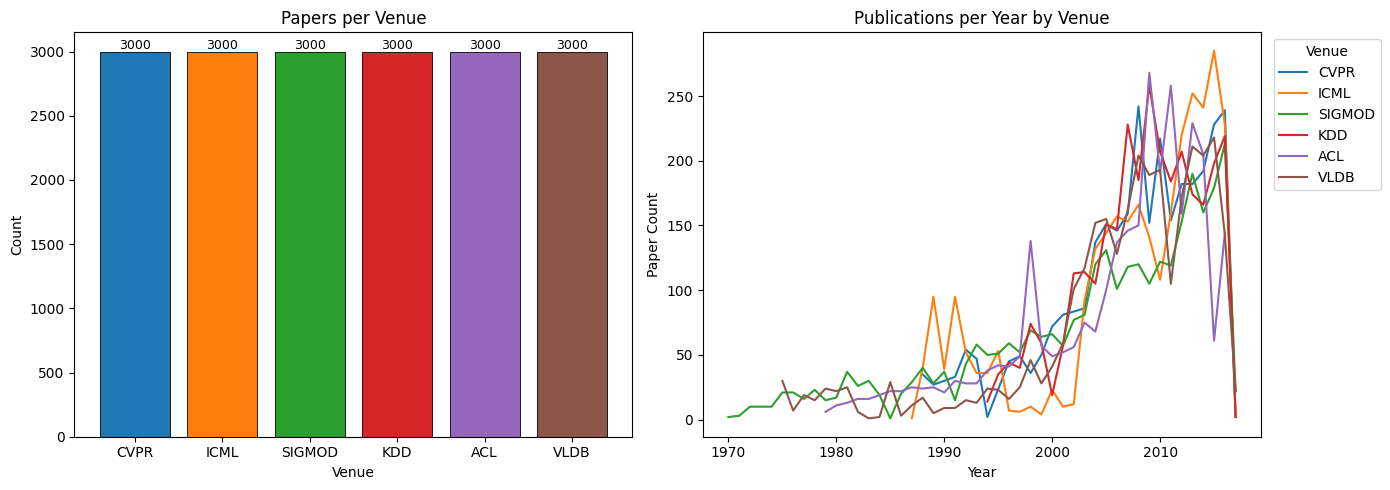

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: papers per venue
counts = df['abbr'].value_counts().reindex(abbr_list)
axes[0].bar(counts.index, counts.values,
            color=[palette[a] for a in counts.index], edgecolor='k', linewidth=0.6)
axes[0].set_title('Papers per Venue')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Venue')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# Line chart: publications per year per venue
year_counts = df.groupby(['year', 'abbr']).size().reset_index(name='count')
for abbr in abbr_list:
    sub = year_counts[year_counts['abbr'] == abbr].sort_values('year')
    axes[1].plot(sub['year'], sub['count'], label=abbr, color=palette[abbr], linewidth=1.5)
axes[1].set_title('Publications per Year by Venue')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Paper Count')
axes[1].legend(title='Venue', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('./data/a2_papers_per_venue_year.png', dpi=150, bbox_inches='tight')
plt.show()


/var/folders/29/xh7j1v_n19n6v0hgbv0s4xpm0000gn/T/ipykernel_36052/335042727.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_per_venue, labels=abbr_list, patch_artist=True,


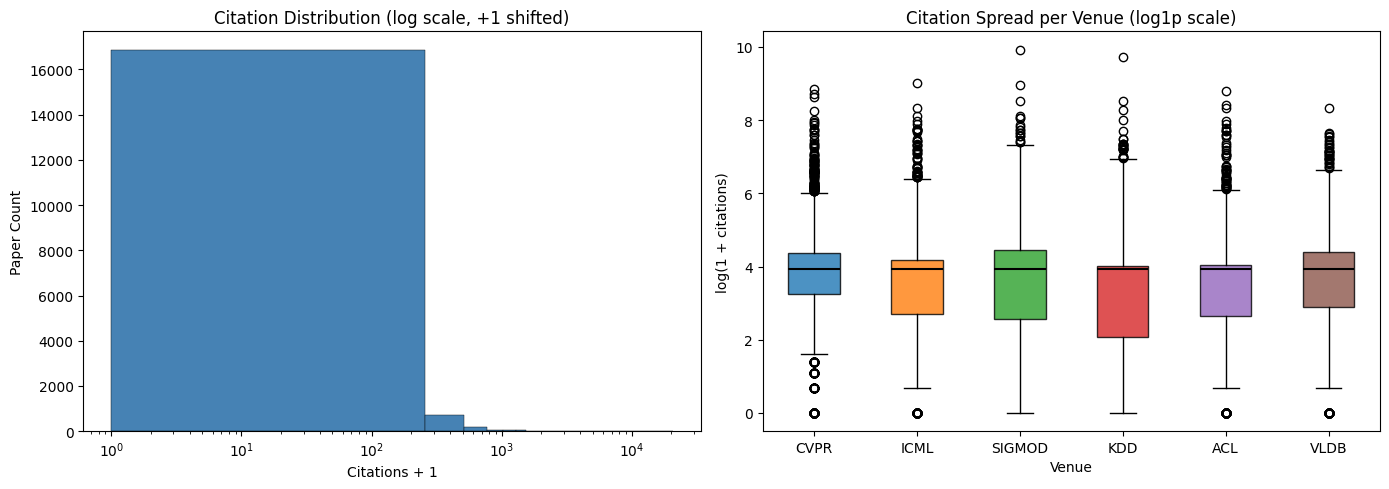

Citation stats per venue:
         mean  median    max
abbr                        
ACL      74.6    50.0   6578
CVPR    102.0    50.0   7021
ICML     88.3    50.0   8121
KDD      84.6    50.0  16624
SIGMOD  111.8    50.0  20548
VLDB     88.9    50.0   4116


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — log scale
citations = df['n_citation'].clip(lower=0)
axes[0].hist(citations + 1, bins=80, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_title('Citation Distribution (log scale, +1 shifted)')
axes[0].set_xlabel('Citations + 1')
axes[0].set_ylabel('Paper Count')

# Boxplot per venue
data_per_venue = [np.log1p(df[df['abbr'] == a]['n_citation'].values) for a in abbr_list]
bp = axes[1].boxplot(data_per_venue, labels=abbr_list, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch, abbr in zip(bp['boxes'], abbr_list):
    patch.set_facecolor(palette[abbr])
    patch.set_alpha(0.8)
axes[1].set_title('Citation Spread per Venue (log1p scale)')
axes[1].set_xlabel('Venue')
axes[1].set_ylabel('log(1 + citations)')

plt.tight_layout()
plt.savefig('./data/a2_citation_distributions.png', dpi=150)
plt.show()

print("Citation stats per venue:")
print(df.groupby('abbr')['n_citation'].agg(['mean', 'median', 'max']).round(1).to_string())


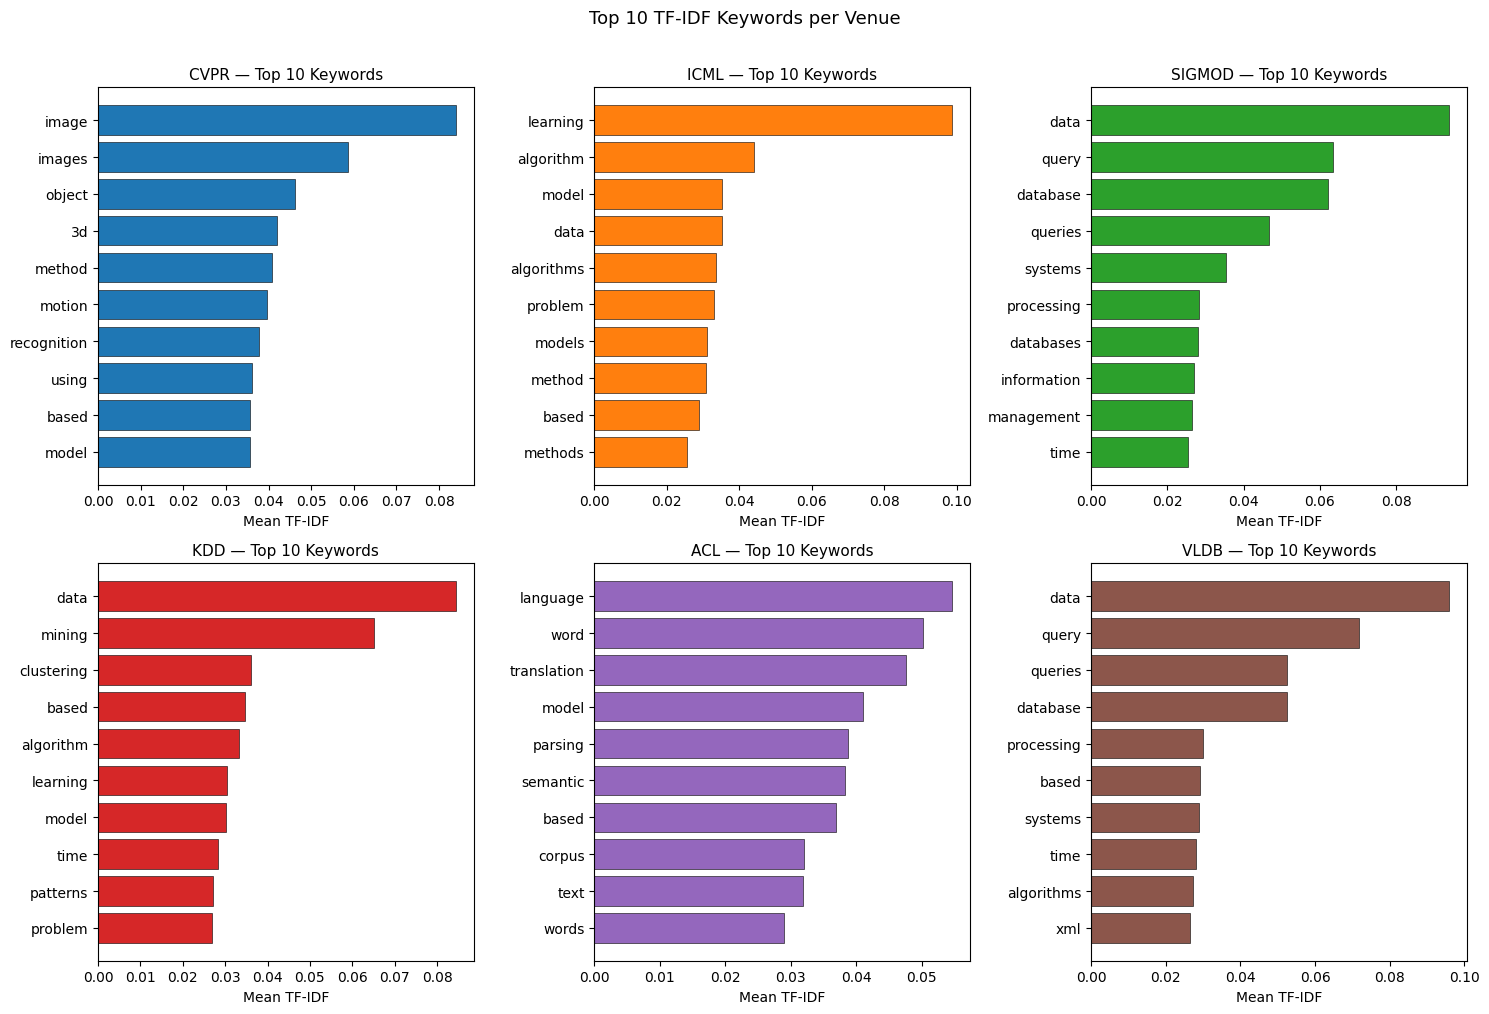

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, venue in enumerate(venues):
    abbr     = venue_abbr[venue]
    mask     = (df['venue'] == venue).to_numpy()
    mean_vec = np.asarray(tfidf_matrix[mask].mean(axis=0)).flatten()
    top_idx  = mean_vec.argsort()[::-1][:10]
    top_words  = [feature_names[i] for i in top_idx]
    top_scores = mean_vec[top_idx]

    ax = axes[ax_idx]
    ax.barh(top_words[::-1], top_scores[::-1],
            color=palette[abbr], edgecolor='k', linewidth=0.4)
    ax.set_title(f'{abbr} — Top 10 Keywords', fontsize=11)
    ax.set_xlabel('Mean TF-IDF')

plt.suptitle('Top 10 TF-IDF Keywords per Venue', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./data/a2_top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()


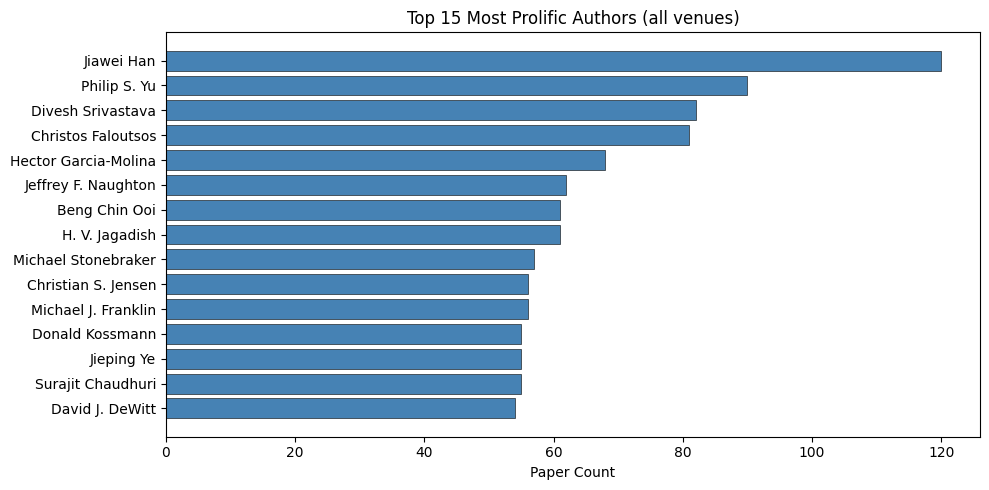

Top 5 Authors per Venue:

  CVPR:
           author  paper_count  avg_citations
       Jieping Ye           55           63.2
         Wei Wang           50          104.3
     Eric P. Xing           41           76.5
         Rong Jin           39           57.6
Charu C. Aggarwal           35          221.7

  ICML:
            author  paper_count  avg_citations
        Jiawei Han          120          226.2
      Philip S. Yu           90          213.7
Christos Faloutsos           81          206.8
        Jieping Ye           55           63.2
          Lei Chen           53           59.3

  SIGMOD:
              author  paper_count  avg_citations
          Jiawei Han          120          226.2
        Philip S. Yu           90          213.7
   Divesh Srivastava           82          116.7
  Christos Faloutsos           81          206.8
Hector Garcia-Molina           68          180.4

  KDD:
              author  paper_count  avg_citations
          Jiawei Han          120    

In [8]:
# Global top 15 authors by paper count
top15 = author_df.nlargest(15, 'paper_count')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top15['author'][::-1], top15['paper_count'][::-1],
        color='steelblue', edgecolor='k', linewidth=0.4)
ax.set_title('Top 15 Most Prolific Authors (all venues)')
ax.set_xlabel('Paper Count')
plt.tight_layout()
plt.savefig('./data/a2_top_authors_global.png', dpi=150)
plt.show()

# Top 5 per venue
print("Top 5 Authors per Venue:\n")
for venue in venues:
    abbr = venue_abbr[venue]
    sub  = author_df[author_df['venues'].apply(lambda vs: venue in vs)]
    top5 = sub.nlargest(5, 'paper_count')[['author', 'paper_count', 'avg_citations']].copy()
    top5['avg_citations'] = top5['avg_citations'].round(1)
    print(f"  {abbr}:")
    print(top5.to_string(index=False))
    print()


Paper-level PCA  PC1=0.031  PC2=0.020  total=0.052


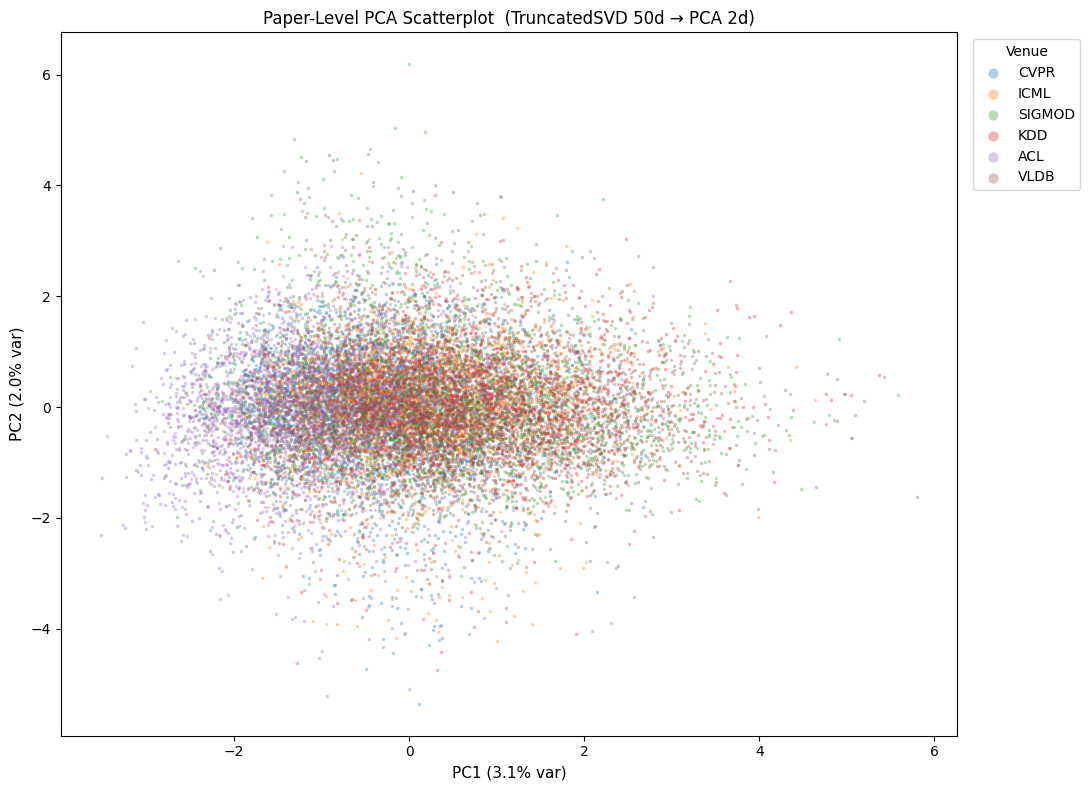

In [9]:
# Paper-level: TruncatedSVD(50) → StandardScaler → PCA(2)
svd_a2    = TruncatedSVD(n_components=50, random_state=42)
x_lsa     = svd_a2.fit_transform(tfidf_matrix)
x_lsa_sc  = StandardScaler().fit_transform(x_lsa)

pca_a2    = PCA(n_components=2, random_state=42)
paper_pca = pca_a2.fit_transform(x_lsa_sc)
np.save('./data/paper_pca_2d.npy', paper_pca)

ev = pca_a2.explained_variance_ratio_
print(f"Paper-level PCA  PC1={ev[0]:.3f}  PC2={ev[1]:.3f}  total={ev.sum():.3f}")

fig, ax = plt.subplots(figsize=(11, 8))
for abbr in abbr_list:
    mask = df['abbr'] == abbr
    ax.scatter(paper_pca[mask, 0], paper_pca[mask, 1],
               label=abbr, color=palette[abbr], alpha=0.35, s=6, linewidths=0)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% var)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% var)', fontsize=11)
ax.set_title('Paper-Level PCA Scatterplot  (TruncatedSVD 50d → PCA 2d)', fontsize=12)
ax.legend(title='Venue', markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('./data/a2_paper_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
summary = df.groupby('abbr').agg(
    paper_count   = ('id', 'count'),
    avg_citations = ('n_citation', 'mean'),
    med_citations = ('n_citation', 'median'),
    year_min      = ('year', 'min'),
    year_max      = ('year', 'max'),
).reset_index()
summary['avg_citations'] = summary['avg_citations'].round(1)
summary['med_citations'] = summary['med_citations'].round(1)
summary['year_range'] = summary['year_min'].astype(str) + '–' + summary['year_max'].astype(str)
summary = summary.drop(columns=['year_min', 'year_max']).set_index('abbr')

print("=== A2 EDA Summary Statistics ===")
print(summary.to_string())


=== A2 EDA Summary Statistics ===
        paper_count  avg_citations  med_citations year_range
abbr                                                        
ACL            3000           74.6           50.0  1979–2016
CVPR           3000          102.0           50.0  1988–2017
ICML           3000           88.3           50.0  1987–2017
KDD            3000           84.6           50.0  1994–2017
SIGMOD         3000          111.8           50.0  1970–2017
VLDB           3000           88.9           50.0  1975–2017


## A3: Co-Author Network

In [25]:
# A3 Cell 1: Build co-author graph
import itertools

df_net = pd.read_parquet('./data/df_clean.parquet')

venue_abbr_a3 = {
    'computer vision and pattern recognition':                 'CVPR',
    'international conference on machine learning':            'ICML',
    'international conference on management of data':          'SIGMOD',
    'knowledge discovery and data mining':                     'KDD',
    'meeting of the association for computational linguistics': 'ACL',
    'very large data bases':                                   'VLDB',
}

G = nx.Graph()
for _, row in df_net.iterrows():
    authors = list(row['authors'])
    if len(authors) < 2:
        continue
    for a, b in itertools.combinations(authors, 2):
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

print(f"Nodes (authors):            {G.number_of_nodes():,}")
print(f"Edges (co-author pairs):    {G.number_of_edges():,}")

Nodes (authors):            25,957
Edges (co-author pairs):    79,704


In [26]:
# A3 Cell 2: Assign primary venue and venue_count per node
exploded = df_net.explode('authors').rename(columns={'authors': 'author'})

primary_venue = (
    exploded.groupby('author')['venue']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
venue_count = (
    exploded.groupby('author')['venue']
    .nunique()
    .to_dict()
)

nx.set_node_attributes(G, primary_venue, 'primary_venue')
nx.set_node_attributes(G, venue_count,   'venue_count')

print("Node attributes set: primary_venue, venue_count")
multi_venue_authors = sum(1 for _, d in G.nodes(data=True) if d.get('venue_count', 1) >= 2)
print(f"Authors in ≥2 venues (bridge candidates): {multi_venue_authors:,}")

Node attributes set: primary_venue, venue_count
Authors in ≥2 venues (bridge candidates): 4,295


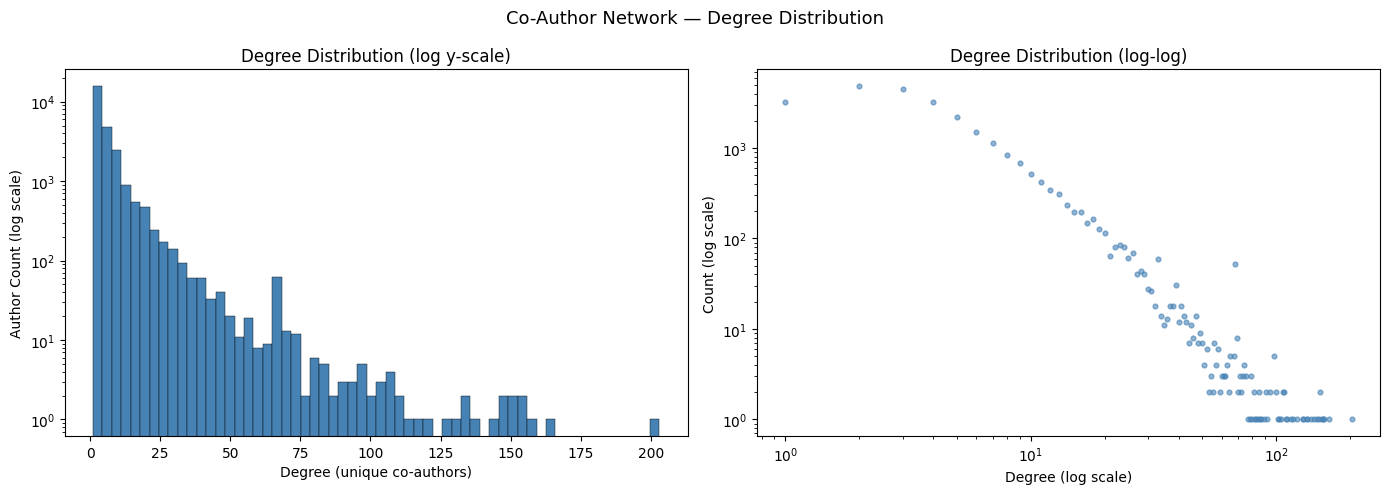

Degree — max: 203,  mean: 6.1,  median: 4.0


In [27]:
# A3 Cell 3: Degree distribution
degrees_arr = np.array([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log y-axis
axes[0].hist(degrees_arr, bins=60, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title('Degree Distribution (log y-scale)')
axes[0].set_xlabel('Degree (unique co-authors)')
axes[0].set_ylabel('Author Count (log scale)')

# Log-log scatter to check power-law behavior
deg_counts = pd.Series(degrees_arr).value_counts().sort_index()
axes[1].scatter(deg_counts.index, deg_counts.values, alpha=0.6, s=12, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Degree Distribution (log-log)')
axes[1].set_xlabel('Degree (log scale)')
axes[1].set_ylabel('Count (log scale)')

plt.suptitle('Co-Author Network — Degree Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('./data/a3_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Degree — max: {degrees_arr.max()},  mean: {degrees_arr.mean():.1f},  median: {np.median(degrees_arr):.1f}")

In [28]:
# A3 Cell 4: Bridge authors — cross-venue connectors
paper_count_map = exploded.groupby('author').size().to_dict()
venues_list_map  = (
    exploded.groupby('author')['venue']
    .apply(lambda x: ', '.join(sorted(x.unique())))
    .to_dict()
)

bridge_rows = []
for node, data in G.nodes(data=True):
    if data.get('venue_count', 1) >= 2:
        bridge_rows.append({
            'author':       node,
            'home_venue':   venue_abbr_a3.get(data.get('primary_venue', ''), data.get('primary_venue', '')),
            'venues':       venues_list_map.get(node, ''),
            'paper_count':  paper_count_map.get(node, 0),
            'degree':       G.degree(node),
            'venue_count':  data['venue_count'],
        })

bridge_df_a3 = (
    pd.DataFrame(bridge_rows)
    .sort_values('degree', ascending=False)
    .reset_index(drop=True)
)

print(f"Bridge authors (venue_count ≥ 2): {len(bridge_df_a3):,}\n")
print("Top 20 Bridge Authors:")
print(bridge_df_a3[['author', 'home_venue', 'venues', 'paper_count', 'degree']].head(20).to_string(index=False))

Bridge authors (venue_count ≥ 2): 4,295

Top 20 Bridge Authors:
               author home_venue                                                                                                                                                                                                             venues  paper_count  degree
           Jiawei Han        KDD international conference on machine learning, international conference on management of data, knowledge discovery and data mining, meeting of the association for computational linguistics, very large data bases          120     203
   Christos Faloutsos        KDD                                                           international conference on machine learning, international conference on management of data, knowledge discovery and data mining, very large data bases           81     164
        Samuel Madden     SIGMOD                                                                                                             

Largest connected component: 20,542 nodes, 72,353 edges
Visualization subgraph:      300 nodes, 3808 edges


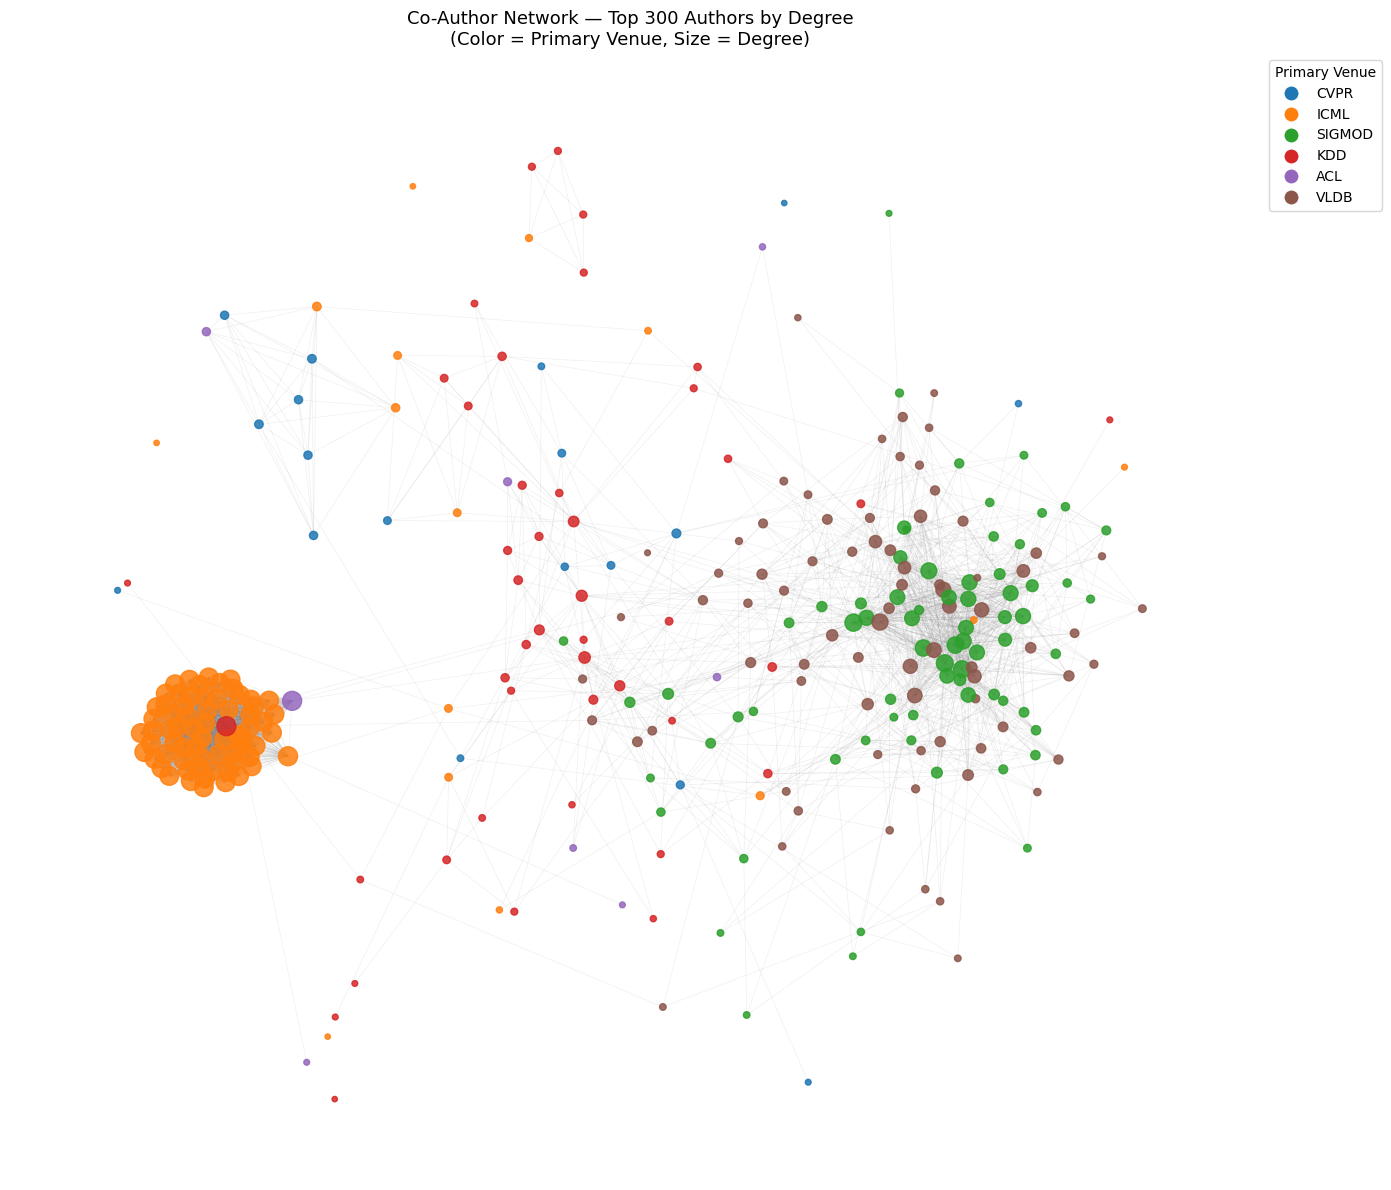

In [29]:
# A3 Cell 5: Network visualization (largest connected component, top N by degree)
components_sorted = sorted(nx.connected_components(G), key=len, reverse=True)
gcc = G.subgraph(components_sorted[0]).copy()
print(f"Largest connected component: {gcc.number_of_nodes():,} nodes, {gcc.number_of_edges():,} edges")

TOP_N = 300
top_nodes = sorted(gcc.nodes(), key=lambda n: gcc.degree(n), reverse=True)[:TOP_N]
subgraph  = gcc.subgraph(top_nodes).copy()
print(f"Visualization subgraph:      {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

venue_colors = {
    'computer vision and pattern recognition':                 '#1f77b4',
    'international conference on machine learning':            '#ff7f0e',
    'international conference on management of data':          '#2ca02c',
    'knowledge discovery and data mining':                     '#d62728',
    'meeting of the association for computational linguistics': '#9467bd',
    'very large data bases':                                   '#8c564b',
}

node_colors = [venue_colors.get(subgraph.nodes[n].get('primary_venue', ''), '#aaaaaa') for n in subgraph.nodes()]
node_sizes  = [15 + subgraph.degree(n) * 2.5 for n in subgraph.nodes()]

pos = nx.spring_layout(subgraph, k=0.4, seed=42)

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.12, width=0.5, edge_color='gray')
nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes, alpha=0.85)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=venue_colors[v], markersize=11,
               label=venue_abbr_a3[v])
    for v in venue_colors
]
ax.legend(handles=legend_handles, title='Primary Venue',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_title(
    f'Co-Author Network — Top {TOP_N} Authors by Degree\n'
    '(Color = Primary Venue, Size = Degree)',
    fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.savefig('./data/a3_network_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# A3 Cell 6: Summary stats + handoff
n_components  = nx.number_connected_components(G)
density       = nx.density(G)

# Clustering coefficient on a 2k-node sample to avoid hanging on the full graph
sample_nodes  = list(G.nodes())[:2000]
avg_clustering = nx.average_clustering(G.subgraph(sample_nodes))

print("=== A3 Network Summary ===")
print(f"Total nodes (authors):          {G.number_of_nodes():,}")
print(f"Total edges (co-author pairs):  {G.number_of_edges():,}")
print(f"Connected components:           {n_components:,}")
print(f"Largest component size:         {len(components_sorted[0]):,} nodes")
print(f"Graph density:                  {density:.6f}")
print(f"Avg clustering (2k sample):     {avg_clustering:.4f}")
print(f"Bridge authors (≥2 venues):     {len(bridge_df_a3):,}")

# Save bridge authors for C1 (Classification) and B2 (Anomaly) handoff
bridge_df_a3.to_parquet('./data/bridge_authors.parquet')
print("\nSaved: ./data/bridge_authors.parquet")
print("Columns:", bridge_df_a3.columns.tolist())

=== A3 Network Summary ===
Total nodes (authors):          25,957
Total edges (co-author pairs):  79,704
Connected components:           1,557
Largest component size:         20,542 nodes
Graph density:                  0.000237
Avg clustering (2k sample):     0.6293
Bridge authors (≥2 venues):     4,295

Saved: ./data/bridge_authors.parquet
Columns: ['author', 'home_venue', 'venues', 'paper_count', 'degree', 'venue_count']


## B1: Venue & Paper Clustering

In [11]:
venue_df = pd.read_parquet('./data/venue_df.parquet')
df_clean =pd.read_parquet('./data/df_clean.parquet')
tfidf_matrix = sp.load_npz('./data/tfidf_matrix.npz')
venue_tfidf= np.load('./data/venue_tfidf.npy')
venue_tfidf_zscore= np.load('./data/venue_tfidf_zscore.npy')
venue_tfidf_minmax= np.load('./data/venue_tfidf_minmax.npy')
with open('./data/vectorizer.pkl', 'rb') as f:
    vectorizer=pickle.load(f)

venues=venue_df['venue'].tolist()
feature_names =vectorizer.get_feature_names_out()
venue_abbr = {
    'computer vision and pattern recognition':               'CVPR',
    'international conference on machine learning':          'ICML',
    'international conference on management of data':        'SIGMOD',
    'knowledge discovery and data mining':                   'KDD',
    'meeting of the association for computational linguistics': 'ACL',
    'very large data bases':                                 'VLDB',
}
short=[venue_abbr.get(v, v.split()[0].upper()) for v in venues]
print(f"Venues: {short}")
print(f"Papers: {len(df_clean)}, TF-IDF: {tfidf_matrix.shape}")

Venues: ['CVPR', 'ICML', 'SIGMOD', 'KDD', 'ACL', 'VLDB']
Papers: 18000, TF-IDF: (18000, 1000)


K-Means Clustering
  k=2: labels=[1 1 0 1 1 0], silhouette=0.219
  k=3: labels=[1 1 0 1 2 0], silhouette=0.210
  k=4: labels=[2 1 0 1 3 0], silhouette=0.179
  k=5: labels=[2 4 0 1 3 0], silhouette=0.154

Best k=2 (silhouette=0.219)


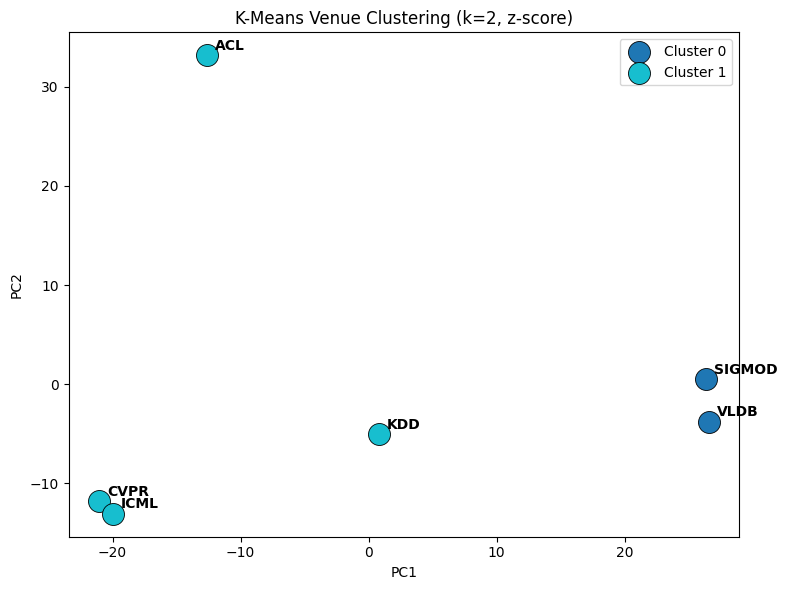


Top 10 keywords per cluster:
  Cluster 0 ['SIGMOD', 'VLDB']: ['optimizer', 'dbms', 'join', 'schema', 'joins', 'tuples', 'querying', 'execution', 'integration', 'stored']
  Cluster 1 ['CVPR', 'ICML', 'KDD', 'ACL']: ['improved', 'labeled', 'accuracy', 'applied', 'approach', 'combine', 'test', 'model', 'term', 'modeling']


In [12]:
#K-Means TF-IDF
print("K-Means Clustering")
eps =np.finfo(float).eps

sil_scores_z={}
for k in range(2, len(venues)):
    km =KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred =km.fit_predict(venue_tfidf_zscore)
    sil = silhouette_score(venue_tfidf_zscore, y_pred) if len(set(y_pred)) > 1 else -1.0
    sil_scores_z[k]= (sil, y_pred.copy())
    print(f"  k={k}: labels={y_pred}, silhouette={sil:.3f}")

best_k=max(sil_scores_z, key=lambda k: sil_scores_z[k][0])
km_labels= sil_scores_z[best_k][1]
print(f"\nBest k={best_k} (silhouette={sil_scores_z[best_k][0]:.3f})")

colors=plt.cm.tab10(np.linspace(0, 1, best_k))
fig, ax= plt.subplots(figsize=(8, 6))
for c in range(best_k):
    mask =km_labels == c
    ax.scatter(venue_df['pca_x'][mask], venue_df['pca_y'][mask],
               label = f"Cluster {c}", s=250, color=colors[c], edgecolors='k', linewidths=0.6)
for i in range(len(venues)):
    ax.annotate(short[i], (venue_df['pca_x'].iloc[i], venue_df['pca_y'].iloc[i]),
                fontsize = 10, fontweight='bold', xytext=(6, 4), textcoords='offset points')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means Venue Clustering (k={best_k}, z-score)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 keywords per cluster:")
for c in range(best_k):
    mask =km_labels == c
    cluster_venues=[short[i] for i in range(len(venues)) if mask[i]]
    vec=venue_tfidf_zscore[mask].mean(axis=0)
    top_words = [feature_names[i] for i in vec.argsort()[::-1][:10]]
    print(f"  Cluster {c} {cluster_venues}: {top_words}")

Normalization Impact
  z-score: {'k=2': 0.219, 'k=3': 0.21, 'k=4': 0.179, 'k=5': 0.154}
  min-max: {'k=2': 0.25, 'k=3': 0.221, 'k=4': 0.191, 'k=5': 0.163}


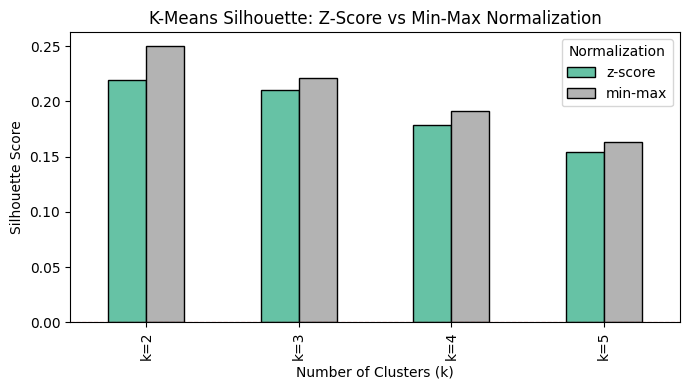

In [13]:
# Normalization Impact: z-score vs min-max
print("Normalization Impact")
norm_data ={'z-score': venue_tfidf_zscore, 'min-max': venue_tfidf_minmax}
norm_results= {}
for norm_name, x_norm in norm_data.items():
    row = {}
    for k in range(2, len(venues)):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        y_pred= km.fit_predict(x_norm)
        sil= silhouette_score(x_norm, y_pred) if len(set(y_pred)) > 1 else -1.0
        row[f"k={k}"] =round(sil, 3)
    norm_results[norm_name]=row
    print(f"  {norm_name}: {row}")

norm_df= pd.DataFrame(norm_results).T
fig, ax = plt.subplots(figsize=(7, 4))
norm_df.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='k')
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-Means Silhouette: Z-Score vs Min-Max Normalization")
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.legend(title="Normalization")
plt.tight_layout()
plt.show()

=== DBSCAN Clustering (venue-level, z-score) ===
  Scanning eps values (min_samples=1):
    eps=   1: clusters=6, noise=0, silhouette=-1.000
    eps=   2: clusters=6, noise=0, silhouette=-1.000
    eps=   3: clusters=6, noise=0, silhouette=-1.000
    eps=   5: clusters=6, noise=0, silhouette=-1.000
    eps=   8: clusters=6, noise=0, silhouette=-1.000
    eps=  12: clusters=6, noise=0, silhouette=-1.000

Chosen eps=1: 6 cluster(s)
  CVPR: cluster 0
  ICML: cluster 1
  SIGMOD: cluster 2
  KDD: cluster 3
  ACL: cluster 4
  VLDB: cluster 5


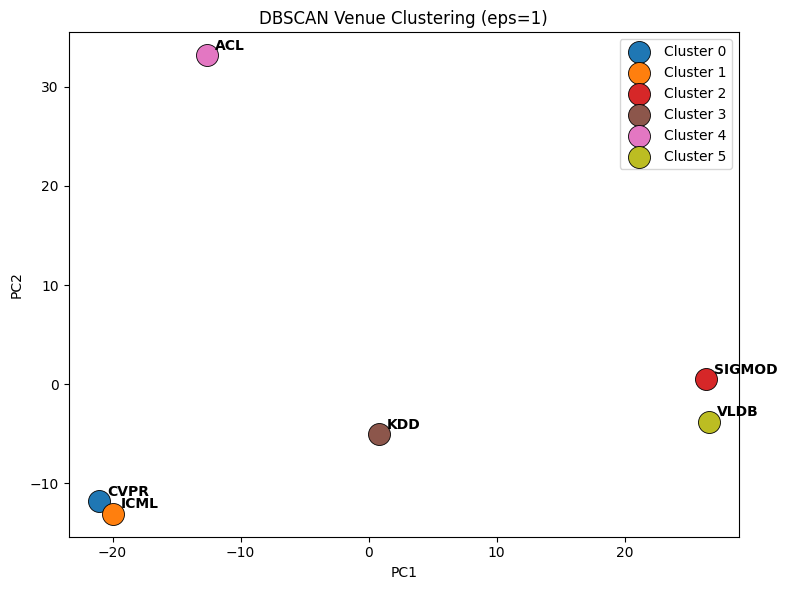

In [14]:
# ── DBSCAN on venue-level TF-IDF (z-score normalized) ───────────────────────
print("=== DBSCAN Clustering (venue-level, z-score) ===")
print("  Scanning eps values (min_samples=1):")
best_eps, best_sil_d=3, -2.0
for eps_val in [1, 2, 3, 5, 8, 12]:
    dbs =DBSCAN(eps=eps_val, min_samples=1)
    y_pred =dbs.fit_predict(venue_tfidf_zscore)
    n_clusters= len(set(y_pred)) - (1 if -1 in y_pred else 0)
    n_noise = list(y_pred).count(-1)
    # silhouette_score requires: 2 <= n_labels <= n_samples-1
    # filter noise (-1) labels before scoring
    valid =y_pred != -1
    n_valid = valid.sum()
    n_valid_clusters=len(set(y_pred[valid]))
    if n_valid_clusters > 1 and n_valid_clusters < n_valid:
        sil= silhouette_score(venue_tfidf_zscore[valid], y_pred[valid])
    else:
        sil=-1.0
    if sil > best_sil_d:
        best_sil_d, best_eps= sil, eps_val
    print(f"    eps={eps_val:4}: clusters={n_clusters}, noise={n_noise}, silhouette={sil:.3f}")

dbs = DBSCAN(eps=best_eps, min_samples=1)
dbs_labels= dbs.fit_predict(venue_tfidf_zscore)
n_clusters =len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
print(f"\nChosen eps={best_eps}: {n_clusters} cluster(s)")
for i, lbl in enumerate(dbs_labels):
    print(f"  {short[i]}: cluster {lbl}" + (" (noise)" if lbl == -1 else ""))

n_colors=max(dbs_labels) + 2
colors_d =plt.cm.tab10(np.linspace(0, 1, max(n_colors, 2)))
fig, ax = plt.subplots(figsize=(8, 6))
seen_labels = set()
for i, (px, py, lbl) in enumerate(zip(venue_df['pca_x'], venue_df['pca_y'], dbs_labels)):
    c=colors_d[lbl] if lbl >= 0 else 'gray'
    marker='X' if lbl == -1 else 'o'
    label =f"Cluster {lbl}" if lbl >= 0 else "Noise"
    ax.scatter(px, py, color=c, s=250, marker=marker, edgecolors='k', linewidths=0.6,
               label= label if label not in seen_labels else "")
    seen_labels.add(label)
    ax.annotate(short[i], (px, py), xytext=(6, 4), textcoords='offset points',
                fontsize = 10, fontweight='bold')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN Venue Clustering (eps={best_eps})")
ax.legend()
plt.tight_layout()
plt.show()

Agglomerative Clustering


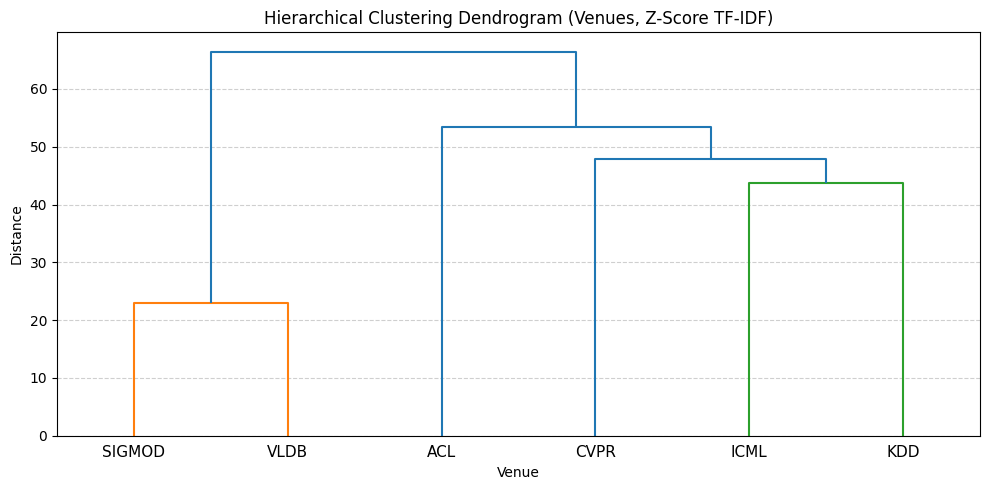

Agglomerative (k=2) silhouette=0.219
  CVPR: cluster 0
  ICML: cluster 0
  SIGMOD: cluster 1
  KDD: cluster 0
  ACL: cluster 0
  VLDB: cluster 1


In [15]:
#Agglomerative Clustering + Dendrogram
print("Agglomerative Clustering")

def plot_dendrogram(model, **kwargs):
    counts=np.zeros(model.children_.shape[0])
    n_samples =len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count=0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i]= current_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

ac =AgglomerativeClustering(n_clusters=None, distance_threshold=0, compute_distances=True)
ac.fit(venue_tfidf_zscore)

plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram (Venues, Z-Score TF-IDF)")
plot_dendrogram(ac, labels=short, truncate_mode=None, leaf_font_size=11)
plt.xlabel("Venue")
plt.ylabel("Distance")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

ac_k =AgglomerativeClustering(n_clusters=best_k)
ac_labels=ac_k.fit_predict(venue_tfidf_zscore)
sil_ac = silhouette_score(venue_tfidf_zscore, ac_labels)
print(f"Agglomerative (k={best_k}) silhouette={sil_ac:.3f}")
for i, lbl in enumerate(ac_labels):
    print(f"  {short[i]}: cluster {lbl}")

Paper-Level Clustering


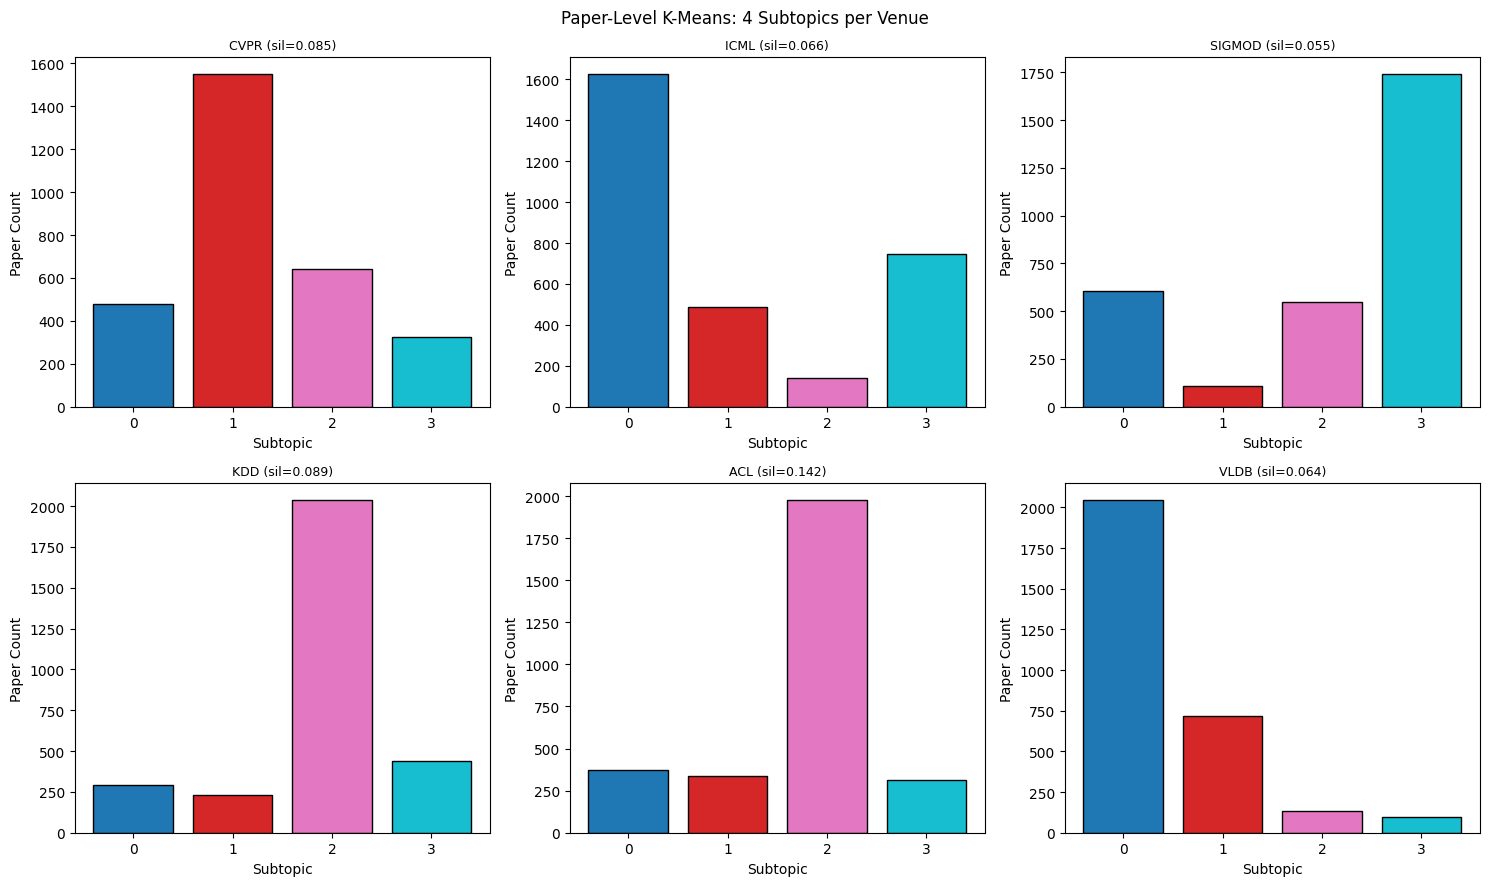


Top 8 keywords per ICML subtopic:
  Subtopic 0 (1626 papers): ['algorithm', 'learning', 'problem', 'algorithms', 'method', 'data', 'classification', 'based']
  Subtopic 1 (486 papers): ['models', 'inference', 'model', 'bayesian', 'latent', 'learning', 'data', 'gaussian']
  Subtopic 2 (140 papers): ['kernel', 'kernels', 'learning', 'algorithm', 'classification', 'problem', 'space', 'methods']
  Subtopic 3 (748 papers): ['learning', 'reinforcement', 'algorithm', 'algorithms', 'based', 'knowledge', 'problem', 'model']


In [16]:
# Paper-Level Clustering
print("Paper-Level Clustering")
N_SUBTOPICS= 4

svd_p= TruncatedSVD(n_components=50, random_state=42)
x_lsa_p = svd_p.fit_transform(tfidf_matrix)
scaler_p =StandardScaler()
x_lsa_scaled=scaler_p.fit_transform(x_lsa_p)

fig, axes= plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_idx, venue in enumerate(venues):
    mask= (df_clean['venue'] == venue).to_numpy()
    x_v =x_lsa_scaled[mask]
    km_p = KMeans(n_clusters=N_SUBTOPICS, random_state=42, n_init=10)
    labels_p=km_p.fit_predict(x_v)
    sil_p =silhouette_score(x_v, labels_p,
                             sample_size= min(len(x_v), 2000), random_state=42)
    ax=axes[ax_idx]
    counts_p = [(labels_p == c).sum() for c in range(N_SUBTOPICS)]
    ax.bar(range(N_SUBTOPICS), counts_p,
           color= plt.cm.tab10(np.linspace(0, 1, N_SUBTOPICS)), edgecolor='k')
    ax.set_title(f"{venue_abbr.get(venue, venue[:8])} (sil={sil_p:.3f})", fontsize=9)
    ax.set_xlabel("Subtopic"); ax.set_ylabel("Paper Count")
    ax.set_xticks(range(N_SUBTOPICS))

plt.suptitle(f"Paper-Level K-Means: {N_SUBTOPICS} Subtopics per Venue", fontsize=12)
plt.tight_layout()
plt.show()

icml='international conference on machine learning'
mask_icml=(df_clean['venue'] == icml).to_numpy()
km_icml = KMeans(n_clusters=N_SUBTOPICS, random_state=42, n_init=10)
labels_icml=km_icml.fit_predict(x_lsa_scaled[mask_icml])
print("\nTop 8 keywords per ICML subtopic:")
for c in range(N_SUBTOPICS):
    c_mask =labels_icml == c
    raw= np.asarray(tfidf_matrix[mask_icml][c_mask].mean(axis=0)).flatten()
    kws= [feature_names[i] for i in raw.argsort()[::-1][:8]]
    print(f"  Subtopic {c} ({c_mask.sum()} papers): {kws}")

## B2: Anomaly Detection

In [17]:
#Anomaly Detection

tfidf_matrix =sp.load_npz('./data/tfidf_matrix.npz')
df_clean =pd.read_parquet('./data/df_clean.parquet')
venue_tfidf = np.load('./data/venue_tfidf.npy')
venue_df= pd.read_parquet('./data/venue_df.parquet')
with open('./data/vectorizer.pkl', 'rb') as f:
    vectorizer=pickle.load(f)
feature_names = vectorizer.get_feature_names_out()
venues = venue_df['venue'].tolist()
venue_abbr ={
    'computer vision and pattern recognition':               'CVPR',
    'international conference on machine learning':          'ICML',
    'international conference on management of data':        'SIGMOD',
    'knowledge discovery and data mining':                   'KDD',
    'meeting of the association for computational linguistics': 'ACL',
    'very large data bases':                                 'VLDB',
}

svd_ad=TruncatedSVD(n_components=50, random_state=42)
x_lsa_ad =svd_ad.fit_transform(tfidf_matrix)
scaler_ad = StandardScaler()
x_scaled_ad= scaler_ad.fit_transform(x_lsa_ad)
x_2d= x_scaled_ad[:, :2]

print(f"LSA feature matrix: {x_scaled_ad.shape}")
print(f"Explained variance (top 50): {svd_ad.explained_variance_ratio_.sum():.3f}")

LSA feature matrix: (18000, 50)
Explained variance (top 50): 0.213


IQR /Z-Score Anomaly Detection
Z-Score (|z|>3): 90 anomalies (0.5%)
IQR:              175 anomalies (1.0%)


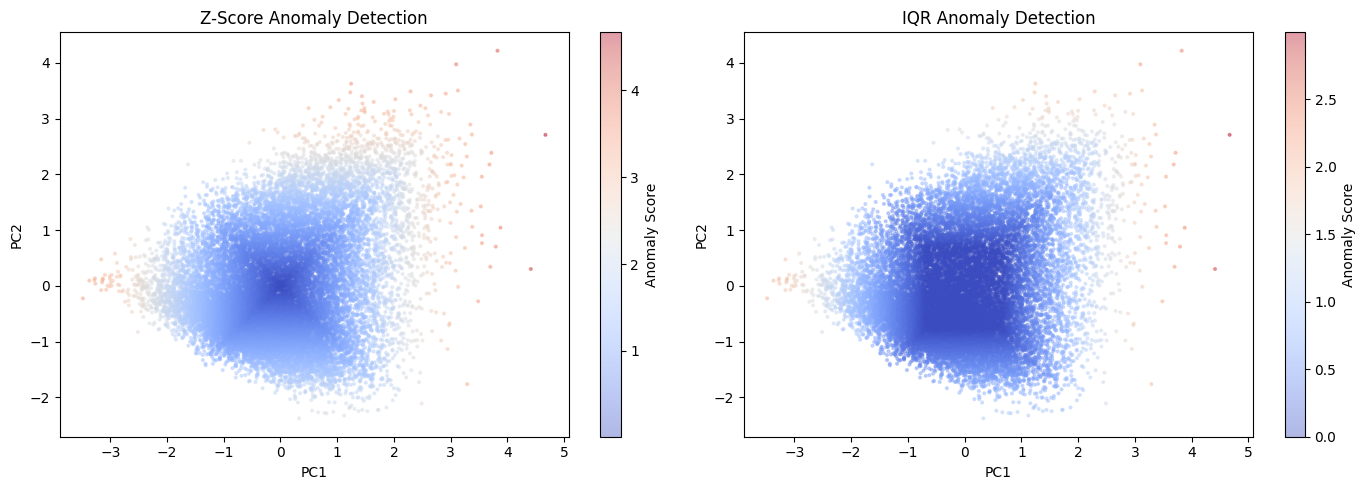

In [18]:
# IQR /Z-Score Anomaly Detection
print("IQR /Z-Score Anomaly Detection")
eps_f =np.finfo(float).eps

z=np.abs(x_2d)
zscore_anomaly = (z > 3).any(axis=1)
zscore_score =z.max(axis=1)
print(f"Z-Score (|z|>3): {zscore_anomaly.sum()} anomalies ({zscore_anomaly.mean()*100:.1f}%)")

q1= np.percentile(x_2d, 25, axis=0)
q3=np.percentile(x_2d, 75, axis=0)
iqr = q3 - q1
iqr_anomaly =((x_2d < q1 - 1.5 * iqr) | (x_2d > q3 + 1.5 * iqr)).any(axis=1)
iqr_score=np.maximum(
    np.maximum(q1 - x_2d, 0) / (iqr + eps_f),
    np.maximum(x_2d - q3, 0) / (iqr + eps_f)
).max(axis=1)
print(f"IQR:              {iqr_anomaly.sum()} anomalies ({iqr_anomaly.mean()*100:.1f}%)")

fig, axes =plt.subplots(1, 2, figsize=(14, 5))
for ax, score, title in zip(axes,
                             [zscore_score, iqr_score],
                             ["Z-Score Anomaly Detection", "IQR Anomaly Detection"]):
    sc= ax.scatter(x_2d[:, 0], x_2d[:, 1], c=score, cmap='coolwarm', alpha=0.4, s=4)
    plt.colorbar(sc, ax=ax, label="Anomaly Score")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
plt.tight_layout()
plt.show()

Isolation Forest
Isolation Forest: 900 anomalies (5.0%)


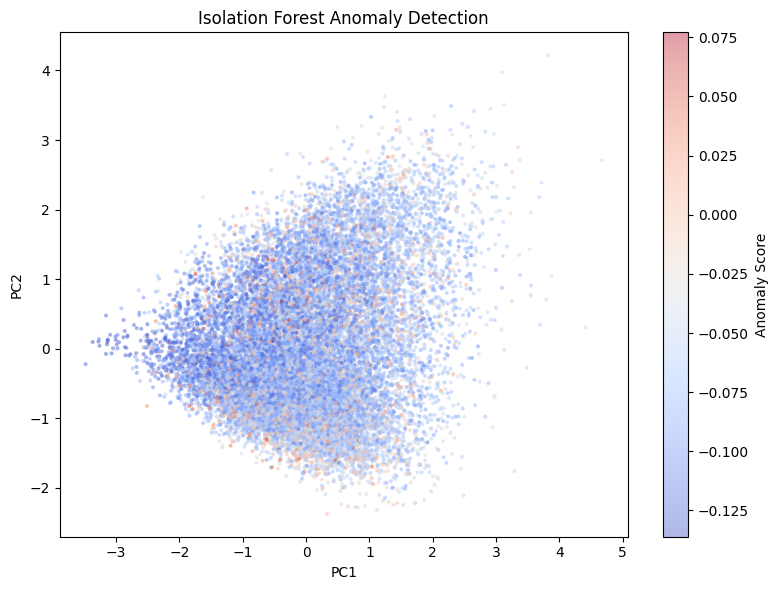


Anomalies per venue (Isolation Forest):
venue
knowledge discovery and data mining                         211
meeting of the association for computational linguistics    196
very large data bases                                       161
computer vision and pattern recognition                     126
international conference on management of data              126
international conference on machine learning                 80


In [19]:
# Isolation Forest
print("Isolation Forest")
iso= IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(x_scaled_ad)
iso_labels=iso.predict(x_scaled_ad)
iso_scores = -iso.decision_function(x_scaled_ad)
iso_anomaly =iso_labels == -1
print(f"Isolation Forest: {iso_anomaly.sum()} anomalies ({iso_anomaly.mean()*100:.1f}%)")

fig, ax =plt.subplots(figsize=(8, 6))
sc= ax.scatter(x_2d[:, 0], x_2d[:, 1], c=iso_scores, cmap='coolwarm', alpha=0.4, s=4)
plt.colorbar(sc, ax=ax, label="Anomaly Score")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Isolation Forest Anomaly Detection")
plt.tight_layout()
plt.show()

print("\nAnomalies per venue (Isolation Forest):")
df_clean['iso_anomaly'] = iso_anomaly
print(df_clean.groupby('venue')['iso_anomaly'].sum().sort_values(ascending=False).to_string())

One-Class SVM
OCSVM:            1343 anomalies (7.5%)


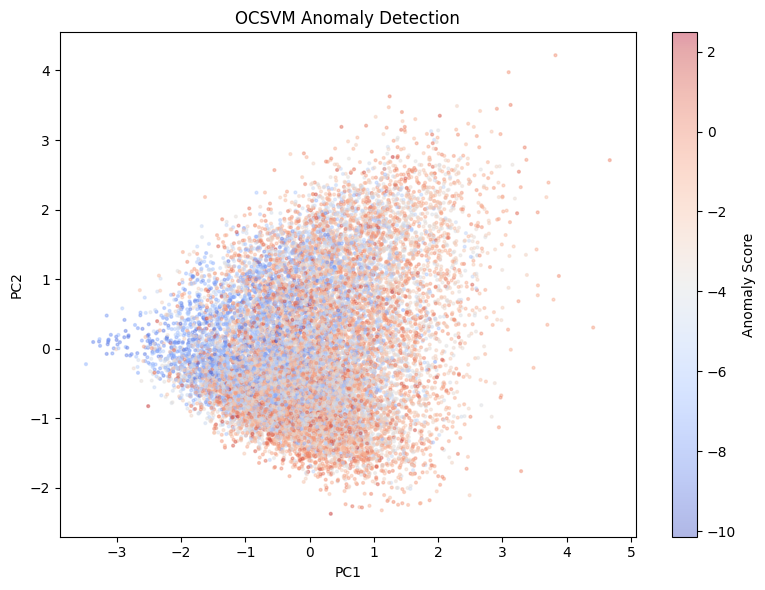

In [20]:
#One-Class SVM
print("One-Class SVM")
np.random.seed(42)
sample_idx = np.random.choice(len(x_scaled_ad), size=3000, replace=False)
x_sample= x_scaled_ad[sample_idx]

ocsvm=OneClassSVM(kernel='rbf', nu=0.05)
ocsvm.fit(x_sample)
ocsvm_scores =-ocsvm.decision_function(x_scaled_ad)
ocsvm_labels = ocsvm.predict(x_scaled_ad)
ocsvm_anomaly=ocsvm_labels == -1
print(f"OCSVM:            {ocsvm_anomaly.sum()} anomalies ({ocsvm_anomaly.mean()*100:.1f}%)")

fig, ax=plt.subplots(figsize=(8, 6))
sc= ax.scatter(x_2d[:, 0], x_2d[:, 1], c=ocsvm_scores, cmap='coolwarm', alpha=0.4, s=4)
plt.colorbar(sc, ax=ax, label="Anomaly Score")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("OCSVM Anomaly Detection")
plt.tight_layout()
plt.show()

In [21]:
#Method Comparison and Case Study
print("Method Comparison")
print(f"{'Method':<24} {'Flagged':>8} {'%':>7}")
print("-" * 44)
for name, anomaly in [("Z-Score (|z|>3)", zscore_anomaly),
                      ("IQR",             iqr_anomaly),
                      ("Isolation Forest", iso_anomaly),
                      ("OCSVM",           ocsvm_anomaly)]:
    print(f"  {name:<22} {anomaly.sum():>8} {anomaly.mean()*100:>6.1f}%")

agree_all = iso_anomaly & ocsvm_anomaly & zscore_anomaly
print(f"\nAgreed by all 3 methods: {agree_all.sum()} papers")

print("\nTop 10 Most Anomalous Papers")
top_idx =iso_scores.argsort()[::-1][:10]
for rank, idx in enumerate(top_idx, 1):
    row=df_clean.iloc[idx]
    p_vec= np.asarray(tfidf_matrix[idx].todense()).flatten()
    top_kws = [feature_names[i] for i in p_vec.argsort()[::-1][:6]]
    print(f"\n  #{rank}  Title : {str(row['title'])[:80]}")
    print(f"       Venue : {venue_abbr.get(row['venue'], row['venue'])}")
    print(f"       Year  : {row['year']}  |  Score: {iso_scores[idx]:.3f}")
    print(f"       Keywords: {top_kws}")

Method Comparison
Method                    Flagged       %
--------------------------------------------
  Z-Score (|z|>3)              90    0.5%
  IQR                         175    1.0%
  Isolation Forest            900    5.0%
  OCSVM                      1343    7.5%

Agreed by all 3 methods: 2 papers

Top 10 Most Anomalous Papers

  #1  Title : mining temporal co-orientation pattern from spatio-temporal databases
       Venue : KDD
       Year  : 2007  |  Score: 0.077
       Keywords: ['temporal', 'pattern', 'spatial', 'patterns', 'mining', 'spatio']

  #2  Title : editorial: special issue on web content mining
       Venue : KDD
       Year  : 2004  |  Score: 0.077
       Keywords: ['web', 'mining', 'content', 'knowledge', 'structure', 'information']

  #3  Title : should we translate the documents or the queries in cross-language information r
       Venue : ACL
       Year  : 1999  |  Score: 0.071
       Keywords: ['translation', 'query', 'document', 'retrieval', 'systems', 'i

## B3: Cross Venue Anomaly Profiling

In [22]:
#Anomaly Profiling

venue_tfidf=np.load('./data/venue_tfidf.npy')
venue_df= pd.read_parquet('./data/venue_df.parquet')
venues =venue_df['venue'].tolist()
abbr_list = [venue_abbr.get(v, v[:6]) for v in venues]

x_anomaly =np.asarray(tfidf_matrix[iso_anomaly].todense())
cos_sim= cosine_similarity(x_anomaly, venue_tfidf)

df_anom=df_clean[iso_anomaly].copy().reset_index(drop=True)
df_anom['home_venue']= df_anom['venue']
df_anom['best_fit_venue'] =[venues[i] for i in cos_sim.argmax(axis=1)]
df_anom['best_fit_score']=cos_sim.max(axis=1)
df_anom['home_sim']=[cos_sim[r, venues.index(df_anom.loc[r, 'home_venue'])]
                              for r in range(len(df_anom))]
df_anom['misplaced'] =df_anom['home_venue'] != df_anom['best_fit_venue']

misplaced = df_anom[df_anom['misplaced']]
print(f"Anomalous papers : {len(df_anom)}")
print(f"Misplaced (DNA)  : {len(misplaced)} ({len(misplaced)/len(df_anom)*100:.1f}%)")

flow= (misplaced
        .groupby(['home_venue', 'best_fit_venue'])
        .size().reset_index(name='count')
        .sort_values('count', ascending=False))
flow['home_abbr'] = flow['home_venue'].map(venue_abbr)
flow['fit_abbr'] = flow['best_fit_venue'].map(venue_abbr)
print("\nTop misplacements (home → best fit):")
print(flow[['home_abbr', 'fit_abbr', 'count']].to_string(index=False))

Anomalous papers : 900
Misplaced (DNA)  : 271 (30.1%)

Top misplacements (home → best fit):
home_abbr fit_abbr  count
   SIGMOD     VLDB     58
     VLDB      KDD     41
     VLDB   SIGMOD     26
   SIGMOD      KDD     24
      KDD     ICML     21
      KDD     VLDB     17
     ICML     CVPR     11
     ICML      KDD      9
      KDD      ACL      6
     ICML      ACL      6
     CVPR     ICML      5
      ACL      KDD      5
      ACL     ICML      5
     VLDB      ACL      5
   SIGMOD      ACL      5
      ACL     VLDB      4
      KDD     CVPR      3
   SIGMOD     CVPR      3
     VLDB     CVPR      3
      KDD   SIGMOD      3
     CVPR      ACL      2
      ACL   SIGMOD      2
     VLDB     ICML      2
     ICML     VLDB      2
     CVPR     VLDB      2
      ACL     CVPR      1


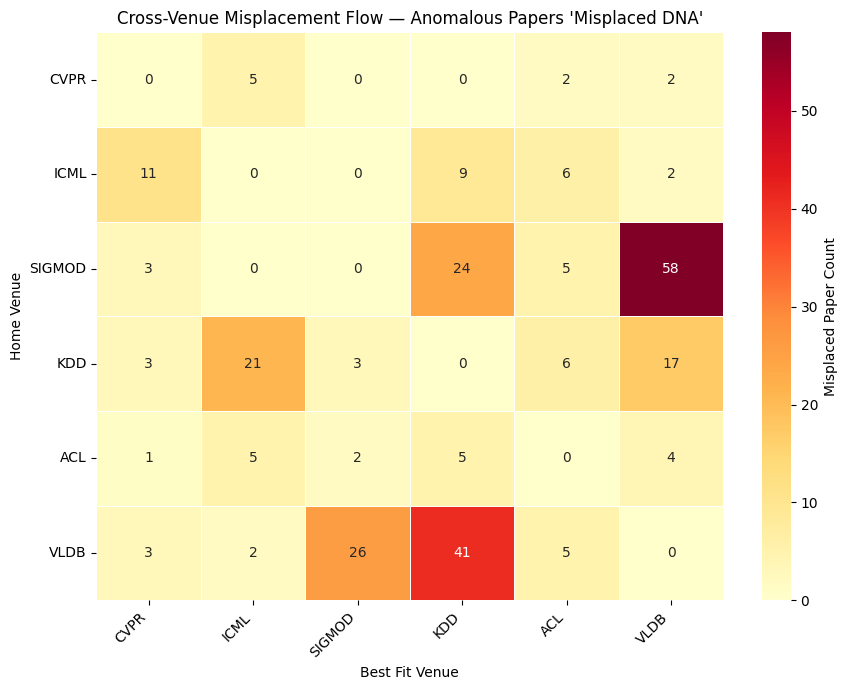

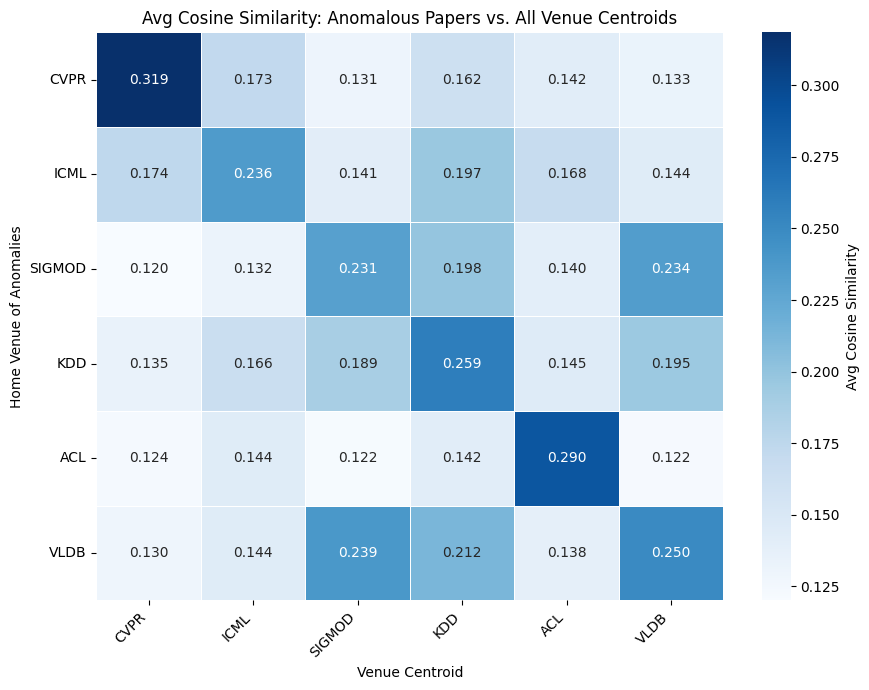

In [23]:
#Flow Diagram:Misplacement Heatmap
n= len(venues)
v_idx={v: i for i, v in enumerate(venues)}
flow_matrix =np.zeros((n, n))
for _, row in flow.iterrows():
    hi=v_idx.get(row['home_venue'])
    bi=v_idx.get(row['best_fit_venue'])
    if hi is not None and bi is not None:
        flow_matrix[hi, bi]= row['count']

fig, ax=plt.subplots(figsize=(9, 7))
sns.heatmap(flow_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels= abbr_list, yticklabels=abbr_list, ax=ax,
            linewidths = 0.5, cbar_kws={'label': 'Misplaced Paper Count'})
ax.set_xlabel("Best Fit Venue")
ax.set_ylabel("Home Venue")
ax.set_title("Cross-Venue Misplacement Flow — Anomalous Papers 'Misplaced DNA'")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#Avg Cosine Similarity heatmap
avg_sim = np.zeros((n, n))
for i, home in enumerate(venues):
    mask_h =(df_anom['home_venue'] == home).values
    if mask_h.sum() > 0:
        avg_sim[i] = cos_sim[mask_h].mean(axis=0)

fig, ax =plt.subplots(figsize=(9, 7))
sns.heatmap(avg_sim, annot=True, fmt='.3f', cmap='Blues',
            xticklabels= abbr_list, yticklabels=abbr_list, ax=ax,
            linewidths =0.5, cbar_kws={'label': 'Avg Cosine Similarity'})
ax.set_xlabel("Venue Centroid")
ax.set_ylabel("Home Venue of Anomalies")
ax.set_title("Avg Cosine Similarity: Anomalous Papers vs. All Venue Centroids")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
#Case Study: Top Misplaced Papers
print("Case Study: Top 10 Most Misplaced Papers")
top_mis= misplaced.nlargest(10, 'best_fit_score')

for rank, (_, row) in enumerate(top_mis.iterrows(), 1):
    id_col ='id' if 'id' in df_clean.columns else 'title'
    paper_idx = df_clean.index[df_clean[id_col] == row[id_col]].tolist()
    kws=[]
    if paper_idx:
        vec= np.asarray(tfidf_matrix[paper_idx[0]].todense()).flatten()
        kws =[feature_names[i] for i in vec.argsort()[::-1][:6]]
    home= venue_abbr.get(row['home_venue'], row['home_venue'])
    fit=venue_abbr.get(row['best_fit_venue'], row['best_fit_venue'])
    print(f"\n  #{rank}  {home} -> {fit}  "
          f"(home_sim={row['home_sim']:.3f}, fit_sim={row['best_fit_score']:.3f})")
    print(f"       Title   : {str(row['title'])[:80]}")
    print(f"       Year    : {row['year']}")
    print(f"       Keywords: {kws}")

print("\nAnomaly Profile per Venue")
for venue in venues:
    sub =df_anom[df_anom['home_venue'] == venue]
    if len(sub) == 0:
        continue
    fit_counts = sub['best_fit_venue'].value_counts()
    pct_mis=sub['misplaced'].mean() * 100
    print(f"\n  {venue_abbr.get(venue, venue)}: {len(sub)} anomalies, {pct_mis:.0f}% misplaced")
    for fit_v, cnt in fit_counts.items():
        tag = "HOME" if fit_v == venue else "misplaced"
        print(f"    -> {venue_abbr.get(fit_v, fit_v)}: {cnt} papers [{tag}]")

Case Study: Top 10 Most Misplaced Papers

  #1  VLDB -> SIGMOD  (home_sim=0.434, fit_sim=0.440)
       Title   : code generation for efficient query processing in managed runtimes
       Year    : 2014
       Keywords: ['query', 'language', 'memory', 'integrated', 'programming', 'application']

  #2  SIGMOD -> VLDB  (home_sim=0.428, fit_sim=0.435)
       Title   : wsq/dsq: a practical approach for combined querying of databases and the web
       Year    : 2000
       Keywords: ['web', 'query', 'queries', 'search', 'database', 'engines']

  #3  SIGMOD -> KDD  (home_sim=0.294, fit_sim=0.426)
       Title   : towards on-line analytical mining in large databases
       Year    : 1998
       Keywords: ['mining', 'data', 'research', 'development', 'analytical', 'construction']

  #4  SIGMOD -> KDD  (home_sim=0.298, fit_sim=0.425)
       Title   : exploratory data analysis using alternating covers of rules and exceptions
       Year    : 2014
       Keywords: ['data', 'rules', 'patterns', 'a